# Chapter 12
## Leveraging similarity

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import confusion_matrix, calinski_harabasz_score, accuracy_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_circles, make_blobs

In [3]:
import os

# Create a 'datasets' directory if it doesn't exist
if not os.path.exists('./datasets'):
    os.makedirs('./datasets')

# Download the penguins.feather file from the GitHub repository
!wget -O ./datasets/penguins.feather https://raw.githubusercontent.com/gikoluo/ML4D2E/main/datasets/penguins.feather

--2026-07-26 15:41:42--  https://raw.githubusercontent.com/gikoluo/ML4D2E/main/datasets/penguins.feather
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17800 (17K) [application/octet-stream]
Saving to: ‘./datasets/penguins.feather’

./datasets/penguins 100%[===================>]  17.38K  --.-KB/s    in 0.002s  

2026-07-26 15:41:42 (9.07 MB/s) - ‘./datasets/penguins.feather’ saved [17800/17800]



In [4]:
penguins = pd.read_feather("./datasets/penguins.feather")
le = LabelEncoder()

features = penguins.iloc[:,1:5]
labels = le.fit_transform(penguins.species)
target_names = dict(zip(range(3), le.classes_))

print(penguins.describe())

print(target_names)

       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
count        333.000000       333.000000         333.000000   333.000000
mean          43.992793        17.164865         200.966967  4207.057057
std            5.468668         1.969235          14.015765   805.215802
min           32.100000        13.100000         172.000000  2700.000000
25%           39.500000        15.600000         190.000000  3550.000000
50%           44.500000        17.300000         197.000000  4050.000000
75%           48.600000        18.700000         213.000000  4775.000000
max           59.600000        21.500000         231.000000  6300.000000
{0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}


## K-means

Explained variance:
[2.754 0.78  0.37  0.108] 


Adelie          [[  0  22 124]
Chinstrap        [  0  63   5]
Gentoo           [119   0   0]]
Iteration: 1 - 2st centroid: [-0.476  0.844  0.239 -0.025]
Iteration: 2 - 2st centroid: [-0.432  0.971  0.293  0.034]
Iteration: 3 - 2st centroid: [-0.408  0.992  0.351  0.036]
Iteration: 4 - 2st centroid: [-0.398  1.004  0.376  0.035]
Iteration: 5 - 2st centroid: [-0.394  1.013  0.384  0.03 ]
Iteration: 6 - 2st centroid: [-0.394  1.013  0.384  0.03 ]
Iteration: 7 - 2st centroid: [-0.394  1.013  0.384  0.03 ]
Iteration: 8 - 2st centroid: [-0.394  1.013  0.384  0.03 ]
Iteration: 9 - 2st centroid: [-0.394  1.013  0.384  0.03 ]
km_centers= [[ 2.013 -0.394 -0.036 -0.006]
 [-0.394  1.013  0.384  0.03 ]
 [-1.597 -0.304 -0.22  -0.014]]
mbkm_centers= [[ 2.042 -0.329 -0.038 -0.011]
 [-1.637 -0.304 -0.199 -0.01 ]
 [-0.442  0.895  0.4    0.02 ]]
km_centers - mbkm_centers: [[-0.029 -0.065  0.003  0.005]
 [ 1.243  1.318  0.583  0.039]
 [-1.155 -1.199 -0.62  

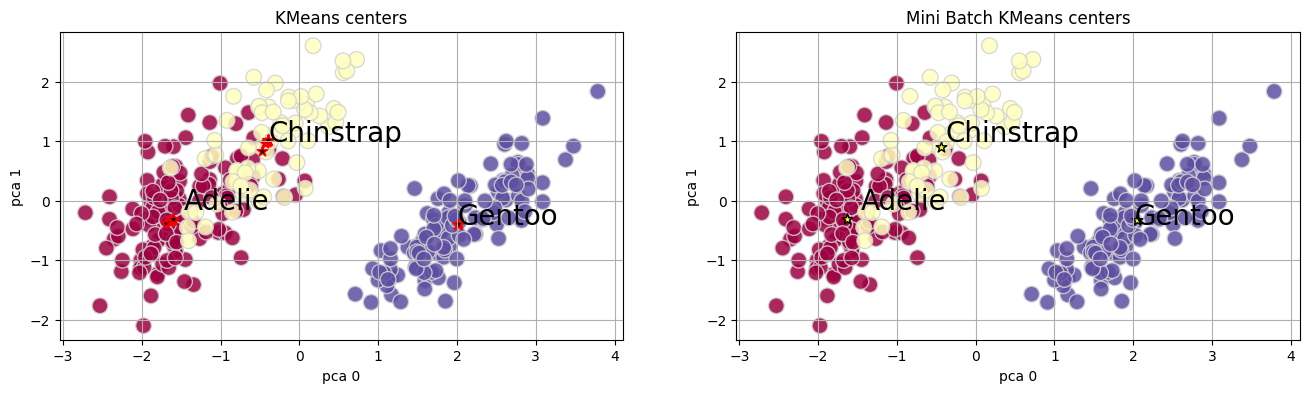

In [10]:
pca = Pipeline([('scaling', StandardScaler()), ('pca', PCA())])




k_means = KMeans(n_clusters=3, init='k-means++', max_iter=999, n_init=10, random_state=101)

mb_k_means = MiniBatchKMeans(n_clusters=3, init='k-means++', max_iter=999, batch_size=30, n_init=10, random_state=101)

pca_features = pca.fit_transform(features)

print('Explained variance:')
print(pca.named_steps['pca'].explained_variance_, '\n\n')

k_means.fit(pca_features)
mb_k_means.fit(pca_features)

cm = str(confusion_matrix(y_true=labels, y_pred=k_means.labels_)).split('\n')
[print(f"{target_names[i]:15} {cm[i]}") for i in range(3)]

km_centers = k_means.cluster_centers_
mbkm_centers = mb_k_means.cluster_centers_

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
ax1.scatter(pca_features[:,0], pca_features[:,1], s=128, c=labels, edgecolors='lightgray', alpha=0.85, cmap='Spectral')
ax1.set_xlabel('pca 0')
ax1.set_ylabel('pca 1')
ax1.set_title('KMeans centers')
ax1.scatter(km_centers[:,0], km_centers[:,1], s=64, marker='*', c='orange', edgecolors='black')
ax1.grid()

for i in range(1, 10):
    k_means2 = KMeans(n_clusters=3, init='k-means++', max_iter=i, n_init=1, random_state=0)
    k_means2.fit(pca_features)
    km_centers2 = k_means2.cluster_centers_
    ax1.scatter(km_centers2[:,0], km_centers2[:,1], s=64, marker='*', c='black', edgecolors='red')
    print('Iteration: {} - 2st centroid: {}'.format(i, km_centers2[0]))



print("km_centers=", km_centers)
print("mbkm_centers=", mbkm_centers)
print("km_centers - mbkm_centers:", (km_centers - mbkm_centers), np.linalg.norm(km_centers - mbkm_centers))

for i in range(3):
    ax1.annotate(target_names[i], (pca_features[labels==i, 0].mean(),
                                   pca_features[labels==i, 1].mean()), fontsize=20)

ax2.scatter(pca_features[:,0], pca_features[:,1], s=128, c=labels, edgecolors='lightgray', alpha=0.85, cmap='Spectral')
ax2.set_xlabel('pca 0')
ax2.set_ylabel('pca 1')
ax2.set_title('Mini Batch KMeans centers')
ax2.scatter(mbkm_centers[:,0], mbkm_centers[:,1], s=64, marker='*', c='yellow', edgecolors='black')
ax2.grid()

for i in range(3):
    ax2.annotate(target_names[i], (pca_features[labels==i, 0].mean(),
                                   pca_features[labels==i, 1].mean()), fontsize=20)

plt.show()

In [9]:
np.set_printoptions(precision=3, suppress=True)

for i in range(1, 10):
    k_means = KMeans(n_clusters=3, init='random', max_iter=i, n_init=1, random_state=0)
    k_means.fit(pca_features)


    print('Iteration: {} - 2st centroid: {}'.format(i, k_means.cluster_centers_[0]))

Iteration: 1 - 2st centroid: [-0.43   1.03   0.194  0.044]
Iteration: 2 - 2st centroid: [-0.398  1.018  0.279  0.035]
Iteration: 3 - 2st centroid: [-0.389  1.011  0.333  0.043]
Iteration: 4 - 2st centroid: [-0.383  1.01   0.367  0.042]
Iteration: 5 - 2st centroid: [-0.394  1.013  0.384  0.03 ]
Iteration: 6 - 2st centroid: [-0.394  1.013  0.384  0.03 ]
Iteration: 7 - 2st centroid: [-0.394  1.013  0.384  0.03 ]
Iteration: 8 - 2st centroid: [-0.394  1.013  0.384  0.03 ]
Iteration: 9 - 2st centroid: [-0.394  1.013  0.384  0.03 ]


### Evaluating

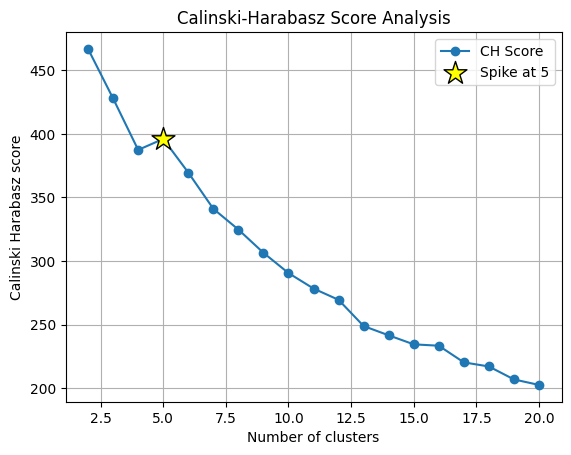

Local peaks (spikes) found at cluster numbers: [5]


In [20]:
ch_scores = []
max_clus = 20
cluster_range = range(2, max_clus+1)

for clus in cluster_range:
    k_means = KMeans(n_clusters=clus, init='k-means++', max_iter=999, n_init=10, random_state=101)
    k_means.fit(pca_features)
    ch = calinski_harabasz_score(pca_features, k_means.labels_)
    ch_scores.append(ch)

plt.plot(cluster_range, ch_scores, 'o-', label='CH Score')

# Find local peaks (spikes)
peaks = []
for i in range(1, len(ch_scores) - 1):
    if ch_scores[i] > ch_scores[i-1] and ch_scores[i] > ch_scores[i+1]:
        peaks.append(cluster_range[i])

# Highlight the spike at 5 with a star
#if 5 in cluster_range:
for i in range(len(peaks)):
    target_idx = list(cluster_range).index(peaks[i])
    plt.scatter(5, ch_scores[target_idx], c='yellow', s=300, marker='*', edgecolors='black', label='Spike at %d' % peaks[i], zorder=5)

plt.xlabel('Number of clusters')
plt.ylabel('Calinski Harabasz score')
plt.title('Calinski-Harabasz Score Analysis')
plt.legend()
plt.grid(True)
plt.show()

print(f"Local peaks (spikes) found at cluster numbers: {peaks}")

Adelie          [[ 0 84  2  0 60]
Chinstrap        [ 0  5 63  0  0]
Gentoo           [62  0  0 57  0]



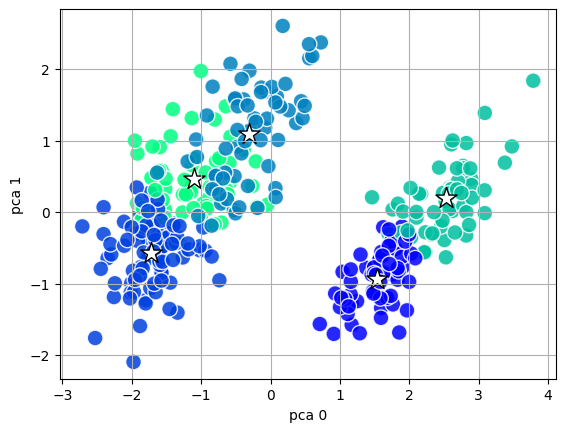

In [21]:
n_clusters=peaks[0]

k_means = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=999, n_init=10, random_state=101)
k_means.fit(pca_features)

km_centers = k_means.cluster_centers_

cm = str(confusion_matrix(y_true=labels, y_pred=k_means.labels_)).split('\n')
[print(f"{target_names[i]:15} {cm[i]}") for i in range(3)]
print()

plt.scatter(pca_features[:,0], pca_features[:,1], s=128, c=k_means.labels_, edgecolors='white', alpha=0.85, cmap='winter')
plt.scatter(km_centers[:,0], km_centers[:,1], s=256, marker='*', c='white', edgecolors='black')
plt.xlabel('pca 0')
plt.ylabel('pca 1')
plt.grid()

plt.show()

## K-Nearest Neighbors

In [22]:
knn = KNeighborsClassifier(metric='euclidean')
kfold = KFold(n_splits=10, shuffle=True, random_state=0)
param_grid = {"n_neighbors": range(1, 16)}

experiment = GridSearchCV(knn, param_grid=param_grid, cv=kfold)

In [23]:
experiment.fit(features, labels)

print(f"Best params: {experiment.best_params_}")
print(f"best cv accuracy: {experiment.best_score_:0.3}")

Best params: {'n_neighbors': 1}
best cv accuracy: 0.859


In [24]:
experiment.fit(pca_features, labels)

print(f"Best params: {experiment.best_params_}")
print(f"best cv accuracy: {experiment.best_score_:0.3}")

Best params: {'n_neighbors': 3}
best cv accuracy: 0.991


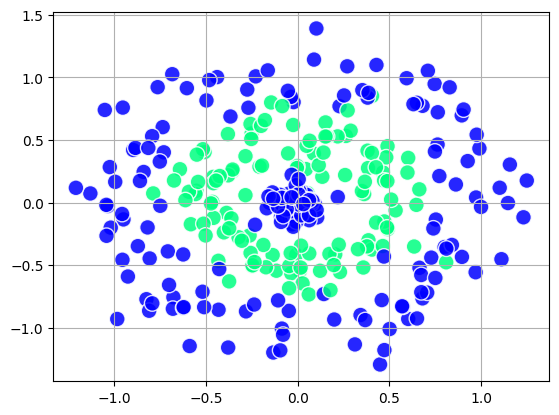

In [32]:
strange_data = make_circles(n_samples=500, shuffle=True, noise=0.15, random_state=101, factor=0.5)


center = make_blobs(n_samples=100, n_features=2, centers=1, cluster_std=0.1, center_box=(0, 0))

# Replaced np.row_stack with np.vstack to resolve DeprecationWarning
first_half = np.vstack((strange_data[0][:250,:], center[0][:50,:]))
first_labels = np.append(strange_data[1][:250], np.zeros(50))
second_half = np.vstack((strange_data[0][250:,:], center[0][50:,:]))
second_labels = np.append(strange_data[1][250:], np.zeros(50))

plt.scatter(first_half[:,0], first_half[:,1], s=128, c=first_labels, edgecolors='white', alpha=0.85, cmap='winter')
plt.grid()

plt.show()

In [39]:
kNN = KNeighborsClassifier(n_neighbors=3, weights='uniform', algorithm='auto', metric='euclidean')

kfold = KFold(n_splits=10, shuffle=True, random_state=0)
param_grid = {"n_neighbors": range(1, 16)}

kNN.fit(first_half, first_labels)

acc1 = accuracy_score(y_true=second_labels, y_pred=kNN.predict(second_half))

knn = KNeighborsClassifier(weights='uniform', algorithm='auto', metric='euclidean')

experiment = GridSearchCV(knn, param_grid=param_grid, cv=kfold)
experiment.fit(first_half, first_labels)
acc2 = accuracy_score(y_true=second_labels, y_pred=experiment.predict(second_half))

print(f"Learning accuracy score 1 (Fixed k=3): {acc1:0.3}\n")

print(f"Learning accuracy score 2 (Optimized): {acc2:0.3}")
print(f"Best k found via search: {experiment.best_params_}")

Learning accuracy score 1 (Fixed k=3): 0.933

Learning accuracy score 2 (Optimized): 0.927
Best k found via search: {'n_neighbors': 6}
